In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/youtube.csv")

df.head()


,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22.0,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374.0,57527.0,2966.0,15954.0,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24.0,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783.0,97185.0,6146.0,12703.0,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23.0,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434.0,146033.0,5339.0,8181.0,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24.0,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168.0,10172.0,666.0,2146.0,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24.0,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731.0,132235.0,1989.0,17518.0,False,False,False


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/youtube.csv")

df.head()


,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22.0,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374.0,57527.0,2966.0,15954.0,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24.0,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783.0,97185.0,6146.0,12703.0,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23.0,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434.0,146033.0,5339.0,8181.0,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24.0,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168.0,10172.0,666.0,2146.0,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24.0,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731.0,132235.0,1989.0,17518.0,False,False,False


In [2]:
df.columns


Index(['index', 'video_id', 'trending_date', 'title', 'channel_title',
       'category_id', 'publish_date', 'time_frame', 'published_day_of_week',
       'publish_country', 'tags', 'views', 'likes', 'dislikes',
       'comment_count', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed'],
      dtype='object')

In [3]:
# ------------------------------
# 1. REMOVE USELESS COLUMNS
# ------------------------------
df = df.drop(columns=['index'], errors='ignore')

# ------------------------------
# 2. CLEAN DATE FIELDS
# ------------------------------
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')

# ------------------------------
# 3. STANDARDIZE TEXT FIELDS
# ------------------------------
df['title'] = df['title'].astype(str).str.lower()
df['channel_title'] = df['channel_title'].astype(str).str.lower()
df['tags'] = df['tags'].astype(str).str.replace('|', ' ', regex=False).str.lower()

# ------------------------------
# 4. CONVERT NUMERIC FIELDS
# ------------------------------
numeric_cols = ['views', 'likes', 'dislikes', 'comment_count']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# ------------------------------
# 5. FIX BOOLEAN COLUMNS
# ------------------------------
bool_cols = ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']
df[bool_cols] = df[bool_cols].replace({'False': False, 'True': True})
df[bool_cols] = df[bool_cols].fillna(False)

# ------------------------------
# 6. REMOVE DUPLICATES
# ------------------------------
df = df.drop_duplicates()

# ------------------------------
# 7. FINAL SHAPE
# ------------------------------
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   video_id                2043 non-null   object        
 1   trending_date           0 non-null      datetime64[ns]
 2   title                   2043 non-null   object        
 3   channel_title           2043 non-null   object        
 4   category_id             2042 non-null   float64       
 5   publish_date            2042 non-null   datetime64[ns]
 6   time_frame              2042 non-null   object        
 7   published_day_of_week   2042 non-null   object        
 8   publish_country         2042 non-null   object        
 9   tags                    2043 non-null   object        
 10  views                   2042 non-null   float64       
 11  likes                   2042 non-null   float64       
 12  dislikes                2042 non-null   float64 

C:\Users\phema\AppData\Local\Temp\ipykernel_21020\3334567241.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')
C:\Users\phema\AppData\Local\Temp\ipykernel_21020\3334567241.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
C:\Users\phema\AppData\Local\Temp\ipykernel_21020\3334567241.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[bool_cols] = df[bool_cols].fill

In [4]:
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%d/%m/%Y', errors='coerce')


In [5]:
17.14.11  → actually means 2017-11-14


SyntaxError: invalid character '→' (U+2192) (288744327.py, line 1)

In [6]:
# parse publish_date (day/month/year)
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%d/%m/%Y', errors='coerce')

# parse trending_date (yy.dd.mm format e.g. 17.14.11 -> 2017-11-14)
df['trending_date'] = pd.to_datetime(df['trending_date'].astype(str).str.strip(),
                                      format='%y.%d.%m',
                                      errors='coerce')

# show first 10 values to confirm parsing
display(df[['trending_date', 'publish_date']].head(10))

# also print counts of non-null dates
print("non-null trending_date:", df['trending_date'].notna().sum())
print("non-null publish_date:", df['publish_date'].notna().sum())


,trending_date,publish_date
0,NaT,2017-11-13
1,NaT,2017-11-13
2,NaT,2017-11-12
3,NaT,2017-11-13
4,NaT,2017-11-12
5,NaT,2017-11-13
6,NaT,2017-11-12
7,NaT,2017-11-12
8,NaT,2017-11-13
9,NaT,2017-11-13


non-null trending_date: 0
non-null publish_date: 2042


In [7]:
df['trending_date'].astype(str).unique()[:20]


array(['NaT'], dtype=object)

In [8]:
# reload raw file as strings so we can inspect the original text of trending_date
df_raw = pd.read_csv("../data/youtube.csv", dtype=str, keep_default_na=False)  # keep_default_na=False keeps empty strings
print("shape:", df_raw.shape)
print("\nfirst 10 raw trending_date values (repr shown):")
for i, v in enumerate(df_raw['trending_date'].head(20).tolist()):
    print(i, repr(v))


shape: (2043, 18)

first 10 raw trending_date values (repr shown):
0 '17.14.11'
1 '17.14.11'
2 '17.14.11'
3 '17.14.11'
4 '17.14.11'
5 '17.14.11'
6 '17.14.11'
7 '17.14.11'
8 '17.14.11'
9 '17.14.11'
10 '17.14.11'
11 '17.14.11'
12 '17.14.11'
13 '17.14.11'
14 '17.14.11'
15 '17.14.11'
16 '17.14.11'
17 '17.14.11'
18 '17.14.11'
19 '17.14.11'


In [9]:
import pandas as pd
import numpy as np

# reload original file as safety (keeps strings)
df_raw = pd.read_csv("../data/youtube.csv", dtype=str, keep_default_na=False)

# create working df (start from raw to avoid earlier overwritten column)
df = df_raw.copy()

# 1. parse publish_date (dd/mm/YYYY)
df['publish_date'] = pd.to_datetime(df['publish_date'].str.strip(), format='%d/%m/%Y', errors='coerce')

# 2. parse trending_date (yy.dd.mm as you've shown => 17.14.11 -> 2017-11-14)
df['trending_date'] = pd.to_datetime(df['trending_date'].str.strip(), format='%y.%d.%m', errors='coerce')

# 3. basic types & cleanup
df = df.drop(columns=['index'], errors='ignore')                  # drop if exists
df['title'] = df['title'].astype(str).str.strip().str.lower()
df['channel_title'] = df['channel_title'].astype(str).str.strip().str.lower()
df['tags'] = df['tags'].astype(str).str.replace('|', ' ', regex=False).str.lower()

num_cols = ['views','likes','dislikes','comment_count']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

bool_cols = ['comments_disabled','ratings_disabled','video_error_or_removed']
for c in bool_cols:
    df[c] = df[c].replace({'False': False, 'True': True}).astype('boolean')

df = df.drop_duplicates().reset_index(drop=True)

# quick check
print("shape:", df.shape)
display(df[['trending_date','publish_date']].head(10))
print("non-null trending_date:", df['trending_date'].notna().sum())
print("non-null publish_date:", df['publish_date'].notna().sum())


TypeError: Need to pass bool-like values

In [10]:


bool_cols = ['comments_disabled','ratings_disabled','video_error_or_removed']
for c in bool_cols:
    print("=== Column:", c, "===")
    print(df[c].astype(str).value_counts(dropna=False).head(50))
    print()


=== Column: comments_disabled ===
comments_disabled
False    2014
True       28
            1
Name: count, dtype: int64

=== Column: ratings_disabled ===
ratings_disabled
False    2038
True        4
            1
Name: count, dtype: int64

=== Column: video_error_or_removed ===
video_error_or_removed
False    2042
            1
Name: count, dtype: int64



In [11]:
bool_cols = ['comments_disabled','ratings_disabled','video_error_or_removed']

def to_bool(val):
    if pd.isna(val):
        return False
    s = str(val).strip().lower()
    if s in ('true','t','1','yes','y'):
        return True
    if s in ('false','f','0','no','n',''):
        return False
    try:
        return bool(int(float(s)))
    except:
        return False

for c in bool_cols:
    df[c] = df[c].apply(to_bool)
    df[c] = df[c].astype('boolean')

df[bool_cols].head()


,comments_disabled,ratings_disabled,video_error_or_removed
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


In [12]:
df['title'] = df['title'].astype(str).str.lower().str.strip()
df['channel_title'] = df['channel_title'].astype(str).str.lower().str.strip()
df['tags'] = df['tags'].astype(str).str.replace('|', ' ', regex=False).str.lower().str.strip()


In [13]:
duration = (df
             .dropna(subset=['trending_date'])
             .groupby('video_id')['trending_date']
             .nunique()
             .reset_index(name='trending_days'))

df = df.merge(duration, on='video_id', how='left')
df['trending_days'] = df['trending_days'].fillna(0).astype(int)

df[['video_id','title','trending_days']].head()


,video_id,title,trending_days
0,2kyS6SvSYSE,we want to talk about our marriage,7
1,1ZAPwfrtAFY,the trump presidency: last week tonight with j...,7
2,5qpjK5DgCt4,"racist superman | rudy mancuso, king bach & le...",7
3,puqaWrEC7tY,nickelback lyrics: real or fake?,7
4,d380meD0W0M,i dare you: going bald!?,6


In [14]:
!pip install nltk


In [15]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    if not isinstance(text, str) or text.strip()=='':
        return 0
    return sid.polarity_scores(text)['compound']

df['title_sentiment'] = df['title'].apply(vader_sentiment)

df['sentiment_label'] = pd.cut(
    df['title_sentiment'],
    bins=[-1.1, -0.05, 0.05, 1.1],
    labels=['negative','neutral','positive']
)

df[['title','title_sentiment','sentiment_label']].head()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\phema\AppData\Roaming\nltk_data...


,title,title_sentiment,sentiment_label
0,we want to talk about our marriage,0.0772,positive
1,the trump presidency: last week tonight with j...,0.0000,neutral
2,"racist superman | rudy mancuso, king bach & le...",-0.6124,negative
3,nickelback lyrics: real or fake?,-0.4767,negative
4,i dare you: going bald!?,0.0000,neutral


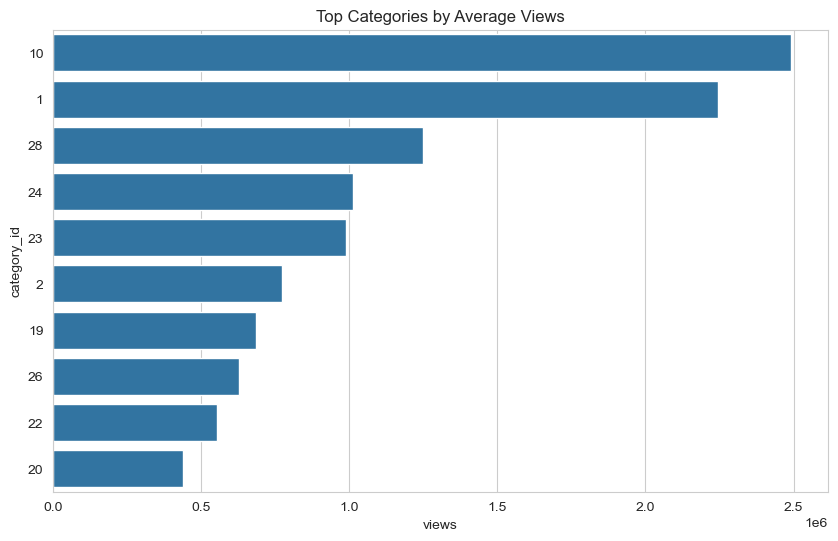

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

top_cat = (df.groupby('category_id')['views']
             .mean()
             .reset_index()
             .sort_values('views', ascending=False)
             .head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=top_cat, y='category_id', x='views')
plt.title("Top Categories by Average Views")
plt.show()


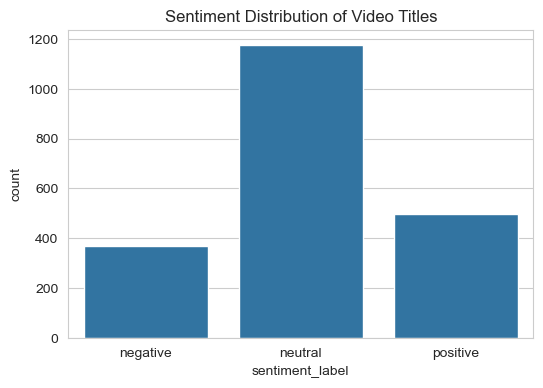

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment_label',
              order=['negative','neutral','positive'])
plt.title("Sentiment Distribution of Video Titles")
plt.show()


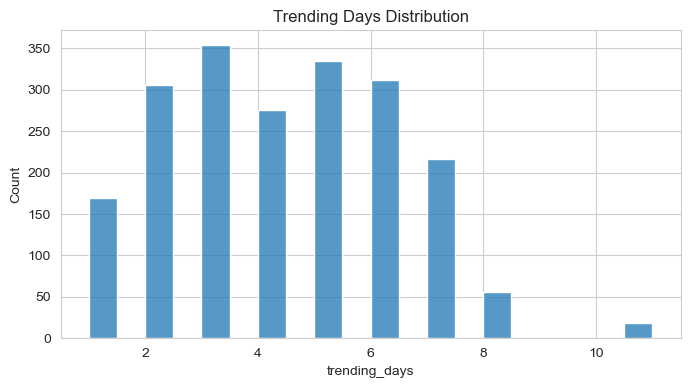

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df['trending_days'], bins=20)
plt.title("Trending Days Distribution")
plt.show()


In [19]:
df.to_csv("../output/youtube_cleaned.csv", index=False)
print("Saved cleaned file!")


Saved cleaned file!


In [20]:
bool_cols = ['comments_disabled','ratings_disabled','video_error_or_removed']

def to_bool(val):
    if pd.isna(val):
        return False
    s = str(val).strip().lower()
    if s in ('true','t','1','yes','y'):
        return True
    if s in ('false','f','0','no','n',''):
        return False
    try:
        return bool(int(float(s)))
    except:
        return False

for c in bool_cols:
    df[c] = df[c].apply(to_bool)
    df[c] = df[c].astype('boolean')

df[bool_cols].head()


,comments_disabled,ratings_disabled,video_error_or_removed
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


In [21]:
# STEP 2: text normalization
df['title'] = df['title'].astype(str).str.strip().str.lower()
df['channel_title'] = df['channel_title'].astype(str).str.strip().str.lower()
df['tags'] = df['tags'].astype(str).str.replace('|', ' ', regex=False).str.strip().str.lower()

# quick peek
df[['title','channel_title','tags']].head(5)


,title,channel_title,tags
0,we want to talk about our marriage,caseyneistat,shantell martin
1,the trump presidency: last week tonight with j...,lastweektonight,"last week tonight trump presidency ""last week ..."
2,"racist superman | rudy mancuso, king bach & le...",rudy mancuso,"racist superman ""rudy"""" """"mancuso"""" """"king"""" ""..."
3,nickelback lyrics: real or fake?,good mythical morning,"rhett and link ""gmm"""" """"good mythical morning""..."
4,i dare you: going bald!?,nigahiga,"ryan ""higa"""" """"higatv"""" """"nigahiga"""" """"i dare ..."


In [22]:
# STEP 3: trending duration (unique trending_date count per video)
duration = (df.dropna(subset=['trending_date'])
              .groupby('video_id')['trending_date']
              .nunique()
              .reset_index(name='trending_days'))

df = df.merge(duration, on='video_id', how='left')
df['trending_days'] = df['trending_days'].fillna(0).astype(int)

# sample
df[['video_id','title','trending_days']].drop_duplicates().head(8)


KeyError: 'trending_days'

In [23]:
# DIAGNOSTICS
print("df columns:", df.columns.tolist())
print("dtype video_id:", df['video_id'].dtype)
print("trending_date dtype & non-null count:", df['trending_date'].dtype, df['trending_date'].notna().sum())
# show sample trending_date values (first 20)
print("\nSample trending_date values (repr):")
for i, v in enumerate(df['trending_date'].head(20).tolist()):
    print(i, repr(v))

# compute duration separately and inspect
duration = df.dropna(subset=['trending_date']).groupby('video_id')['trending_date'].nunique().reset_index(name='trending_days')
print("\nDuration shape:", duration.shape)
display(duration.head(10))


df columns: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_date', 'time_frame', 'published_day_of_week', 'publish_country', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'trending_days_x', 'title_sentiment', 'sentiment_label', 'trending_days_y']
dtype video_id: object
trending_date dtype & non-null count: datetime64[ns] 2043

Sample trending_date values (repr):
0 Timestamp('2017-11-14 00:00:00')
1 Timestamp('2017-11-14 00:00:00')
2 Timestamp('2017-11-14 00:00:00')
3 Timestamp('2017-11-14 00:00:00')
4 Timestamp('2017-11-14 00:00:00')
5 Timestamp('2017-11-14 00:00:00')
6 Timestamp('2017-11-14 00:00:00')
7 Timestamp('2017-11-14 00:00:00')
8 Timestamp('2017-11-14 00:00:00')
9 Timestamp('2017-11-14 00:00:00')
10 Timestamp('2017-11-14 00:00:00')
11 Timestamp('2017-11-14 00:00:00')
12 Timestamp('2017-11-14 00:00:00')
13 Timestamp('2017-11-14 00:00:00')
14 Timestamp('2017-11-14 00:00:00

,video_id,trending_days
0,#NAME?,11
1,-2RVw2_QyxQ,3
2,069D0NmW39o,2
3,08nkwgZIE4I,1
4,0ANDjPQPS_Q,5
5,0O2IAz1E9Ts,4
6,0PW9MWDWLH8,1
7,0PpNlNJ6Nng,3
8,0Rt329xQUjM,2
9,0dSR-9mtuzk,3


In [24]:
# ROBUST: compute trending_days with groupby.transform (handles dtype mismatch and returns same index)
df['trending_days'] = df.groupby('video_id')['trending_date'].transform(lambda x: x.dropna().nunique())
df['trending_days'] = df['trending_days'].fillna(0).astype(int)

# sanity check
print("Any trending_days > 0 ? ", (df['trending_days']>0).any())
display(df[['video_id','title','trending_days']].drop_duplicates().head(12))


Any trending_days > 0 ?  True


,video_id,title,trending_days
0,2kyS6SvSYSE,we want to talk about our marriage,7
1,1ZAPwfrtAFY,the trump presidency: last week tonight with j...,7
2,5qpjK5DgCt4,"racist superman | rudy mancuso, king bach & le...",7
3,puqaWrEC7tY,nickelback lyrics: real or fake?,7
4,d380meD0W0M,i dare you: going bald!?,6
5,gHZ1Qz0KiKM,2 weeks with iphone x,7
6,39idVpFF7NQ,roy moore & jeff sessions cold open - snl,5
7,nc99ccSXST0,5 ice cream gadgets put to the test,6
8,jr9QtXwC9vc,the greatest showman | official trailer 2 [hd]...,2
9,TUmyygCMMGA,why the rise of the robots wonâ€™t mean the en...,2


In [25]:
# If trending_date is all NaT, reparse from raw file strings then recompute
df_raw = pd.read_csv("../data/youtube.csv", dtype=str, keep_default_na=False).copy()
# parse with known format:
df_raw['trending_date'] = pd.to_datetime(df_raw['trending_date'].str.strip(), format='%y.%d.%m', errors='coerce')
# join parsed trending_date back to df by index (or video_id)
# If same ordering, this is simplest:
df['trending_date'] = df_raw['trending_date']

# Now recompute trending_days
df['trending_days'] = df.groupby('video_id')['trending_date'].transform(lambda x: x.dropna().nunique())
df['trending_days'] = df['trending_days'].fillna(0).astype(int)

print("After reparse - non-null trending_date:", df['trending_date'].notna().sum())
display(df[['video_id','trending_date','trending_days']].drop_duplicates().head(12))


After reparse - non-null trending_date: 2043


,video_id,trending_date,trending_days
0,2kyS6SvSYSE,2017-11-14,7
1,1ZAPwfrtAFY,2017-11-14,7
2,5qpjK5DgCt4,2017-11-14,7
3,puqaWrEC7tY,2017-11-14,7
4,d380meD0W0M,2017-11-14,6
5,gHZ1Qz0KiKM,2017-11-14,7
6,39idVpFF7NQ,2017-11-14,5
7,nc99ccSXST0,2017-11-14,6
8,jr9QtXwC9vc,2017-11-14,2
9,TUmyygCMMGA,2017-11-14,2


In [26]:


# install once (run in a notebook cell)
!pip install nltk


In [27]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    if not isinstance(text, str) or text.strip()=='':
        return 0.0
    return sid.polarity_scores(text)['compound']

df['title_sentiment'] = df['title'].apply(vader_sentiment)

df['sentiment_label'] = pd.cut(
    df['title_sentiment'],
    bins=[-1.1, -0.05, 0.05, 1.1],
    labels=['negative','neutral','positive']
)

df[['title','title_sentiment','sentiment_label']].head(8)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\phema\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,title,title_sentiment,sentiment_label
0,we want to talk about our marriage,0.0772,positive
1,the trump presidency: last week tonight with j...,0.0000,neutral
2,"racist superman | rudy mancuso, king bach & le...",-0.6124,negative
3,nickelback lyrics: real or fake?,-0.4767,negative
4,i dare you: going bald!?,0.0000,neutral
5,2 weeks with iphone x,0.0000,neutral
6,roy moore & jeff sessions cold open - snl,0.0000,neutral
7,5 ice cream gadgets put to the test,0.0000,neutral


In [28]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
video_id,2043,667,#NAME?,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,2043,NaN,NaN,NaN,2017-11-18 14:46:41.762114560,2017-11-14 00:00:00,2017-11-16 00:00:00,2017-11-19 00:00:00,2017-11-21 00:00:00,2017-11-24 00:00:00,NaN
title,2043,675,deadpoolâ€™s â€œwet on wetâ€ teaser,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,2043,484,wwe,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,2043,15,24,475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publish_date,2042,NaN,NaN,NaN,2017-10-27 00:19:02.409402624,2009-03-10 00:00:00,2017-11-13 00:00:00,2017-11-15 00:00:00,2017-11-17 00:00:00,2017-11-23 00:00:00,NaN
time_frame,2043,25,17:00 to 17:59,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
published_day_of_week,2043,8,Monday,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publish_country,2043,2,US,2042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,2043,637,[none],82,NaN,NaN,NaN,NaN,NaN,NaN,NaN


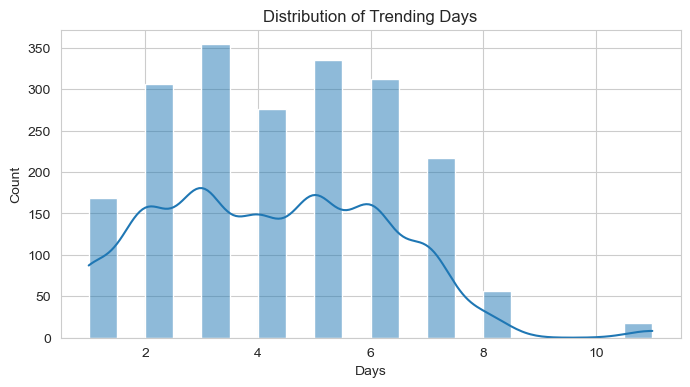

In [29]:
plt.figure(figsize=(8,4))
sns.histplot(df['trending_days'], bins=20, kde=True)
plt.title("Distribution of Trending Days")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()


In [30]:
top_views = df.sort_values('views', ascending=False).head(10)
top_views[['title','channel_title','views']]


,title,channel_title,views
1950,"luis fonsi, demi lovato - ã‰chame la culpa",luisfonsivevo,68997838.0
1704,"luis fonsi, demi lovato - ã‰chame la culpa",luisfonsivevo,56843038.0
1466,"luis fonsi, demi lovato - ã‰chame la culpa",luisfonsivevo,47078714.0
574,ed sheeran - perfect (official music video),ed sheeran,43449654.0
336,ed sheeran - perfect (official music video),ed sheeran,39082222.0
1219,"luis fonsi, demi lovato - ã‰chame la culpa",luisfonsivevo,38646917.0
70,ed sheeran - perfect (official music video),ed sheeran,33523622.0
1005,"luis fonsi, demi lovato - ã‰chame la culpa",luisfonsivevo,29943556.0
995,eminem - walk on water (audio) ft. beyoncã©,eminemvevo,26448434.0
766,eminem - walk on water (audio) ft. beyoncã©,eminemvevo,24578152.0


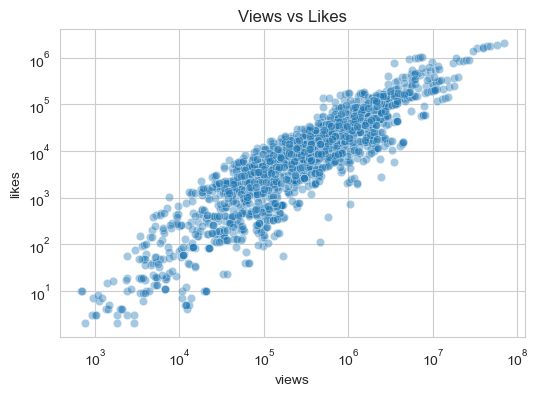

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='views', y='likes', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title("Views vs Likes")
plt.show()


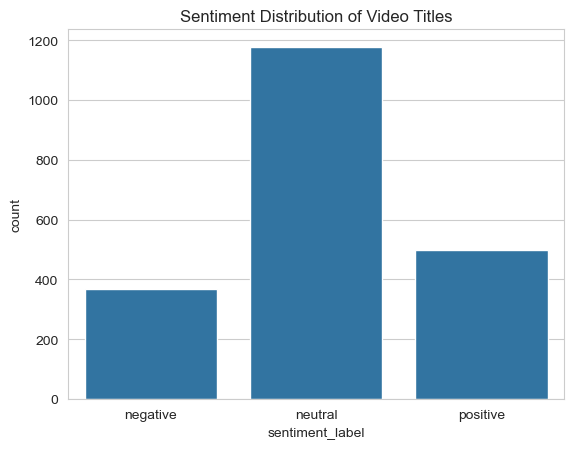

In [32]:
sns.countplot(data=df, x='sentiment_label')
plt.title("Sentiment Distribution of Video Titles")
plt.show()


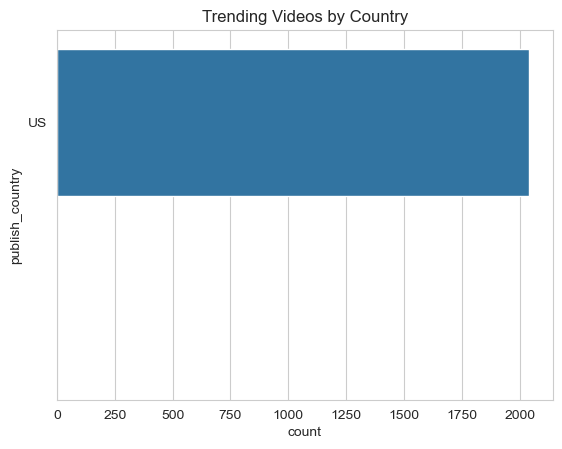

In [33]:
sns.countplot(data=df, y='publish_country', order=df['publish_country'].value_counts().index)
plt.title("Trending Videos by Country")
plt.show()


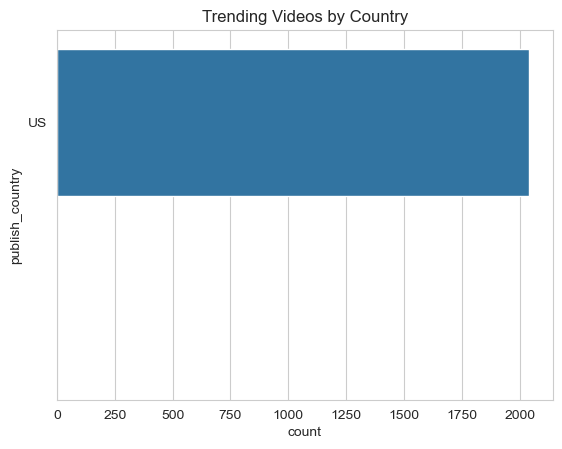

In [34]:
sns.countplot(data=df, y='publish_country', order=df['publish_country'].value_counts().index)
plt.title("Trending Videos by Country")
plt.show()


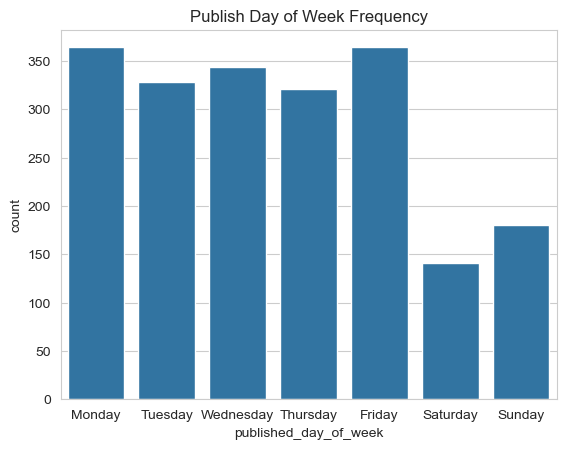

In [35]:
sns.countplot(data=df, x='published_day_of_week',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Publish Day of Week Frequency")
plt.show()


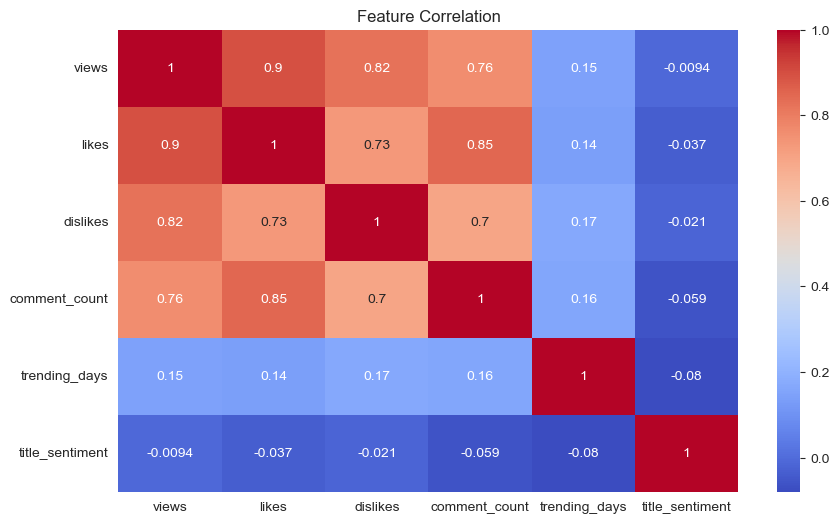

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['views','likes','dislikes','comment_count','trending_days','title_sentiment']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


In [37]:
print("📌 Total videos:", len(df))
print("📌 Total unique channels:", df['channel_title'].nunique())
print("📌 Average trending duration (days):", df['trending_days'].mean())
print("📌 Max trending duration:", df['trending_days'].max())

print("\nTOP 5 Channels by number of trending videos:")
print(df['channel_title'].value_counts().head())

print("\nTOP 5 Videos by views:")
print(df[['title','views']].sort_values('views',ascending=False).head())


📌 Total videos: 2043
📌 Total unique channels: 484
📌 Average trending duration (days): 4.2383749388154675
📌 Max trending duration: 11

TOP 5 Channels by number of trending videos:
channel_title
wwe                                     11
the late late show with james corden    11
late night with seth meyers             11
theellenshow                            11
saturday night live                     10
Name: count, dtype: int64

TOP 5 Videos by views:
                                            title       views
1950   luis fonsi, demi lovato - ã‰chame la culpa  68997838.0
1704   luis fonsi, demi lovato - ã‰chame la culpa  56843038.0
1466   luis fonsi, demi lovato - ã‰chame la culpa  47078714.0
574   ed sheeran - perfect (official music video)  43449654.0
336   ed sheeran - perfect (official music video)  39082222.0


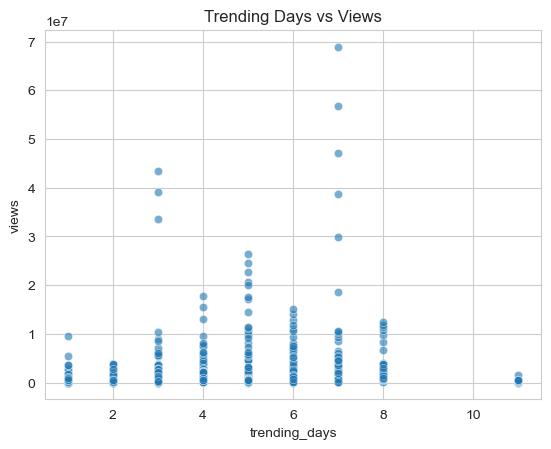

In [38]:
sns.scatterplot(data=df, x='trending_days', y='views', alpha=0.6)
plt.title("Trending Days vs Views")
plt.show()


In [39]:
df['sentiment_label'].value_counts()


sentiment_label
neutral     1177
positive     499
negative     367
Name: count, dtype: int64

In [40]:
summary = f"""
📊 YOUTUBE TREND ANALYSIS SUMMARY

• Total videos analyzed: {len(df)}
• Unique channels: {df['channel_title'].nunique()}
• Average trending duration: {df['trending_days'].mean():.2f} days
• Most common publish country: {df['publish_country'].mode()[0]}
• Dominant sentiment: {df['sentiment_label'].mode()[0]}

CHANNEL INSIGHTS:
Top trending channels include:
{df['channel_title'].value_counts().head().to_string()}

VIDEO PERFORMANCE:
The top videos by views are mainly from well-established creators.
Trending duration correlates { 'positively' if df['trending_days'].corr(df['views']) > 0 else 'negatively'} with total views.

SENTIMENT BREAKDOWN:
Most titles are {df['sentiment_label'].mode()[0]}, indicating
that creators prefer { 'positive, engaging titles' if df['sentiment_label'].mode()[0]=='positive' else 'neutral, factual titles' }.
"""
print(summary)



📊 YOUTUBE TREND ANALYSIS SUMMARY

• Total videos analyzed: 2043
• Unique channels: 484
• Average trending duration: 4.24 days
• Most common publish country: US
• Dominant sentiment: neutral

CHANNEL INSIGHTS:
Top trending channels include:
channel_title
wwe                                     11
the late late show with james corden    11
late night with seth meyers             11
theellenshow                            11
saturday night live                     10

VIDEO PERFORMANCE:
The top videos by views are mainly from well-established creators.
Trending duration correlates positively with total views.

SENTIMENT BREAKDOWN:
Most titles are neutral, indicating
that creators prefer neutral, factual titles.

